In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.preprocessing import OneHotEncoder

import geopandas as gpd
import unicodedata

In [100]:
climate_data = pd.read_parquet('./data/climate_data_from_1982.parquet', engine='fastparquet')
barley_data = pd.read_csv('./data/barley_yield_from_1982.csv', sep=';')

# EDA BARLEY_YIELD_FROM_1982

In [101]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [102]:
print("=== Shape ===")
print(barley_data.shape)

print("\n=== Dtypes ===")
print(barley_data.dtypes)

print("\n=== Head ===")
display(barley_data.head())

=== Shape ===
(3583, 6)

=== Dtypes ===
Unnamed: 0      int64
department        str
year            int64
yield         float64
area          float64
production    float64
dtype: object

=== Head ===


,Unnamed: 0,department,year,yield,area,production
0,82,Ain,1982,3.9501,"16,065.0000","63,458.0000"
1,83,Ain,1983,NaN,"14,500.0000","38,400.0000"
2,84,Ain,1984,4.8226,"15,500.0000","74,750.0000"
3,85,Ain,1985,4.1968,"15,500.0000","65,050.0000"
4,86,Ain,1986,3.5985,"12,900.0000","46,420.0000"


In [103]:
barley_data[barley_data["year"]==2017]['production'].sum() 

np.float64(12086803.579999998)

In [104]:
barley_data[barley_data["year"] == 2017].tail(30)

,Unnamed: 0,department,year,yield,area,production
2440,7852,Morbihan,2017,6.8500,"21,600.0000","147,960.0000"
2477,7971,Moselle,2017,5.4400,"48,230.0000","262,371.2000"
2514,8090,Nievre,2017,6.0600,"32,400.0000","196,344.0000"
2551,8209,Nord,2017,8.2800,"15,090.0000","124,945.2000"
2588,8328,Oise,2017,7.7000,"33,600.0000","258,720.0000"
2625,8447,Orne,2017,6.8600,"23,770.0000","163,062.2000"
2696,8682,Pas_de_Calais,2017,8.1700,"33,300.0000","272,061.0000"
2733,8801,Puy_de_Dome,2017,5.1400,"5,600.0000","28,784.0000"
2770,8920,Pyrenees_Atlantiques,2017,5.6000,"1,562.0000","8,747.2000"
2807,9039,Pyrenees_Orientales,2017,2.9000,75.0000,217.5000


In [105]:
barley_clean = barley_data.copy()

if "Unnamed: 0" in barley_clean.columns:
    barley_clean = barley_clean.drop(columns=["Unnamed: 0"])

mask = (
    barley_clean["yield"].isna() &
    barley_clean["production"].notna() &
    barley_clean["area"].notna() &
    (barley_clean["area"] > 0)
)

barley_clean.loc[mask, "yield"] = barley_clean.loc[mask, "production"] / barley_clean.loc[mask, "area"]
barley_clean

,department,year,yield,area,production
0,Ain,1982,3.9501,"16,065.0000","63,458.0000"
1,Ain,1983,2.6483,"14,500.0000","38,400.0000"
2,Ain,1984,4.8226,"15,500.0000","74,750.0000"
3,Ain,1985,4.1968,"15,500.0000","65,050.0000"
4,Ain,1986,3.5985,"12,900.0000","46,420.0000"
...,...,...,...,...,...
3578,Yvelines,2014,7.7000,"10,180.0000","78,546.0000"
3579,Yvelines,2015,8.0000,"11,420.0000","91,400.5000"
3580,Yvelines,2016,5.3000,"12,225.0000","64,792.5000"
3581,Yvelines,2017,7.3100,"13,735.0000","100,402.8500"


# EDA CLIMATE_DATA_FROM_1982

In [106]:
print("=== Shape ===")
print(climate_data.shape)

print("\n=== Dtypes ===")
print(climate_data.dtypes)

print("\n=== Head ===")
display(climate_data.head())

=== Shape ===
(13540116, 7)

=== Dtypes ===
scenario            object
nom_dep             object
code_dep            object
time        datetime64[ns]
year                 int32
metric              object
value              float32
dtype: object

=== Head ===


,scenario,nom_dep,code_dep,time,year,metric,value
0,historical,Ain,01,1982-01-01 12:00:00,1982,near_surface_air_temperature,276.2923
0,historical,Ain,01,1982-01-02 12:00:00,1982,near_surface_air_temperature,275.0924
0,historical,Ain,01,1982-01-03 12:00:00,1982,near_surface_air_temperature,276.4185
0,historical,Ain,01,1982-01-04 12:00:00,1982,near_surface_air_temperature,278.8934
0,historical,Ain,01,1982-01-05 12:00:00,1982,near_surface_air_temperature,278.8872


In [107]:
climate_clean = climate_data.copy()

In [108]:
metric_counts = climate_clean["metric"].value_counts()
display(metric_counts)

print("\nUnique scenarios:")
display(climate_clean["scenario"].value_counts())

metric
near_surface_air_temperature                  4583500
daily_maximum_near_surface_air_temperature    4478308
precipitation                                 4478308
Name: count, dtype: int64


Unique scenarios:


scenario
ssp1_2_6      3510783
ssp5_8_5      3510783
ssp2_4_5      3300399
historical    3218151
Name: count, dtype: int64

In [109]:
print("Year range:", climate_clean["year"].min(), "→", climate_clean["year"].max())

years_per_scenario = (
    climate_clean
    .groupby("scenario")["year"]
    .agg(["min", "max", "nunique"])
)

display(years_per_scenario)

Year range: 1982 → 2050


,min,max,nunique
scenario,,,
historical,1982,2014,33
ssp1_2_6,2015,2050,36
ssp2_4_5,2015,2050,36
ssp5_8_5,2015,2050,36


# MERGE

In [110]:
barley_key = (
    barley_clean[["department", "year"]]
    .dropna()
    .drop_duplicates()
)

min_year = int(barley_key["year"].min())
max_year = int(barley_key["year"].max())

print("barley year range:", min_year, "->", max_year)
print("barley unique departments:", barley_key["department"].nunique())

barley year range: 1982 -> 2018
barley unique departments: 97


In [111]:
cl = climate_clean.copy()
deps = set(barley_key["department"].astype(str).unique())
cl = cl[cl["nom_dep"].astype(str).isin(deps)].copy()

cl_base = cl[
    ((cl["scenario"] == "historical") & (cl["year"] <= 2014)) |
    ((cl["scenario"] == "ssp2_4_5") & (cl["year"] >= 2015) & (cl["year"] <= max_year))
].copy()

# Important: now scenario is no longer meaningful for training
climate_baseline = cl_base.drop(columns=["scenario"])

In [112]:
cl = climate_clean.copy()
deps = set(barley_key["department"].astype(str).unique())
cl = cl[cl["nom_dep"].astype(str).isin(deps)].copy()

cl_base = cl[
    ((cl["scenario"] == "historical") & (cl["year"] <= 2014)) |
    ((cl["scenario"] == "ssp2_4_5") & (cl["year"] >= 2015) & (cl["year"] <= max_year))
].copy()

cl_base = cl_base.drop(columns=["scenario"])

cl_base["year"]  = cl_base["time"].dt.year
cl_base["month"] = cl_base["time"].dt.month

cl_base["crop_year"] = cl_base["year"] + (cl_base["month"] >= 9).astype(int)
cl_base = cl_base[(cl_base["month"] >= 9) | (cl_base["month"] <= 6)].copy()

# ---- seasonal stats per crop year
agg_stats = ["mean", "std", "min", "max"]

cl_season = (
    cl_base.groupby(["nom_dep", "crop_year", "metric"], observed=True)["value"]
           .agg(agg_stats)
           .reset_index()
)

cl_season_wide = (
    cl_season.pivot_table(
        index=["nom_dep", "crop_year"],
        columns="metric",
        values=agg_stats,
        aggfunc="first"
    )
)

cl_season_wide.columns = [f"{metric}__value_{stat}" for stat, metric in cl_season_wide.columns]
cl_season_wide = (
    cl_season_wide.reset_index()
                  .rename(columns={"nom_dep": "department", "crop_year": "year"})
)

# ---- add seasonal precipitation total (Sep–Jun)
precip_total = (
    cl_base[cl_base["metric"] == "precipitation"]
    .groupby(["nom_dep", "crop_year"], observed=True)["value"]
    .sum()
    .reset_index()
    .rename(columns={"nom_dep": "department", "crop_year": "year", "value": "precipitation__season_SepJun__sum"})
)

cl_season_wide = cl_season_wide.merge(precip_total, on=["department", "year"], how="left", validate="1:1")

# ---- merge into barley (THIS is the correct merge)
df_merged = barley_clean.merge(
    cl_season_wide,
    on=["department", "year"],
    how="left",
    validate="m:1"
)

# MODELS

In [113]:
df_merged.shape

(3583, 18)

In [114]:
df = df_merged.copy()

target_col = "yield"
base_feature_cols = ["department", "year"]
climate_cols = [c for c in df.columns if "__" in c]

feature_cols = base_feature_cols + climate_cols

print("Rows:", df.shape[0])
print("Features:", len(feature_cols))
print("Target missing:", df[target_col].isna().sum())
print("Example features:", feature_cols[:8])

Rows: 3583
Features: 15
Target missing: 122
Example features: ['department', 'year', 'daily_maximum_near_surface_air_temperature__value_max', 'near_surface_air_temperature__value_max', 'precipitation__value_max', 'daily_maximum_near_surface_air_temperature__value_mean', 'near_surface_air_temperature__value_mean', 'precipitation__value_mean']


In [115]:
required_for_model = [target_col] + feature_cols
df_use = df.dropna(subset=required_for_model).copy()

df_use = df_use.sort_values(["year", "department"]).reset_index(drop=True)

In [116]:
X = df_use[feature_cols]
y = df_use[target_col].astype(float).values

# --- build year-based folds (rolling origin)
years = np.array(sorted(df_use["year"].unique()))
n_splits = 5  # adjust
test_size_years = 2  # e.g., predict 2 years ahead per fold

In [117]:
numeric_features = [c for c in feature_cols if c not in ["department", "year"]]
categorical_features = ["department"]

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 13
Categorical features: ['department']


In [118]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_basic = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor_basic = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_basic, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


In [119]:
model_specs = [
    ("Ridge", preprocessor_scaled, Ridge(alpha=1.0)),
    ("ElasticNet", preprocessor_scaled, ElasticNet(alpha=0.01, l1_ratio=0.3, max_iter=10000)),
    ("RandomForest", preprocessor_basic,
        RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=0, n_jobs=-1)),
    ("HistGB", preprocessor_basic,
        HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, random_state=0)),
    ("SVR", preprocessor_scaled, SVR(C=10.0, epsilon=0.1)),
    ("KNN", preprocessor_scaled, KNeighborsRegressor(n_neighbors=15)),
]

In [120]:
folds = []
for k in range(len(years) - (n_splits * test_size_years), len(years), test_size_years):
    train_years = years[:k]
    test_years_ = years[k:k + test_size_years]
    if len(test_years_) < test_size_years:
        continue

    train_idx = df_use["year"].isin(train_years).to_numpy().nonzero()[0]
    test_idx  = df_use["year"].isin(test_years_).to_numpy().nonzero()[0]
    folds.append((train_idx, test_idx))

results = []

for name, prep, model in model_specs:
    fold_scores = []
    for fold_i, (tr, te) in enumerate(folds, 1):
        pipe = Pipeline(steps=[("preprocess", prep), ("model", model)])
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[te])

        fold_scores.append({
            "fold": fold_i,
            "MAE": mean_absolute_error(y[te], pred),
            "RMSE": np.sqrt(mean_squared_error(y[te], pred)),
            "R2": r2_score(y[te], pred),
        })

    fold_df = pd.DataFrame(fold_scores)
    results.append({
        "model": name,
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(ddof=0),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(ddof=0),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std(ddof=0),
        "n_folds": len(fold_df),
    })

leaderboard = pd.DataFrame(results).sort_values("RMSE_mean")
leaderboard

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,n_folds
4,SVR,0.8177,0.1196,1.0249,0.1657,0.3279,0.1997,5
3,HistGB,0.8623,0.1098,1.0575,0.1273,0.2986,0.1451,5
0,Ridge,0.8838,0.2978,1.0735,0.3584,0.2174,0.5057,5
1,ElasticNet,0.9425,0.2089,1.1313,0.2387,0.1417,0.4581,5
5,KNN,0.9369,0.1110,1.1744,0.1666,0.1294,0.2067,5
2,RandomForest,0.9700,0.1643,1.1887,0.1938,0.1049,0.2507,5


In [121]:
best_name = leaderboard.iloc[0]["model"]
best_prep, best_model = [(prep, model) for (name, prep, model) in model_specs if name == best_name][0]

best_pipe = Pipeline(steps=[
    ("preprocess", best_prep),
    ("model", best_model),
])

tr_idx, te_idx = folds[-1]

best_pipe.fit(X.iloc[tr_idx], y[tr_idx])

pi = permutation_importance(
    best_pipe,
    X.iloc[te_idx],
    y[te_idx],
    n_repeats=20,
    random_state=0,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

feature_names = X.columns.to_numpy()

pi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(pi_df.head(25))

,feature,importance_mean,importance_std
6,near_surface_air_temperature__value_mean,0.3926,0.0589
0,department,0.3233,0.0302
14,precipitation__season_SepJun__sum,0.2198,0.0370
5,daily_maximum_near_surface_air_temperature__va...,0.2015,0.0375
7,precipitation__value_mean,0.1122,0.0468
9,near_surface_air_temperature__value_min,0.0597,0.0264
11,daily_maximum_near_surface_air_temperature__va...,0.0536,0.0217
12,near_surface_air_temperature__value_std,0.0249,0.0489
1,year,0.0000,0.0000
10,precipitation__value_min,0.0000,0.0000


## Predictions

In [122]:
import matplotlib.pyplot as plt

# --- Build crop-year seasonal features per scenario (you already did most of this)
cl = climate_clean.copy()
deps = set(barley_key["department"].astype(str).unique())
cl = cl[cl["nom_dep"].astype(str).isin(deps)].copy()

cl["year"] = cl["time"].dt.year
cl["month"] = cl["time"].dt.month
cl["crop_year"] = cl["year"] + (cl["month"] >= 9).astype(int)

# Sep–Jun only
cl = cl[(cl["month"] >= 9) | (cl["month"] <= 6)].copy()

future_crop_years = range(2020, 2050)
scenarios = ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]

cl_fut = cl[
    cl["crop_year"].isin(future_crop_years) &
    cl["scenario"].isin(scenarios)
].copy()

# Seasonal stats per scenario
cl_season = (
    cl_fut.groupby(["nom_dep", "crop_year", "scenario", "metric"], observed=True)["value"]
          .agg(["mean", "std", "min", "max"])
          .reset_index()
)

cl_season_wide = (
    cl_season.pivot_table(
        index=["nom_dep", "crop_year", "scenario"],
        columns="metric",
        values=["mean", "std", "min", "max"],
        aggfunc="first"
    )
)

cl_season_wide.columns = [f"{m}__value_{stat}" for stat, m in cl_season_wide.columns]
cl_season_wide = (
    cl_season_wide.reset_index()
                  .rename(columns={"nom_dep": "department", "crop_year": "year"})
)

# Add Sep–Jun precipitation SUM (optional but recommended)
precip_season_sum = (
    cl_fut[cl_fut["metric"] == "precipitation"]
    .groupby(["nom_dep", "crop_year", "scenario"], observed=True)["value"]
    .sum()
    .reset_index()
    .rename(columns={
        "nom_dep": "department",
        "crop_year": "year",
        "value": "precipitation__season_SepJun__sum"
    })
)

cl_season_wide = cl_season_wide.merge(
    precip_season_sum,
    on=["department", "year", "scenario"],
    how="left",
    validate="m:1"
)

# --- Predict using the SAME feature set as training
df_future = cl_season_wide.copy()

print("df_future shape:", df_future.shape)

df_future shape: (8010, 16)


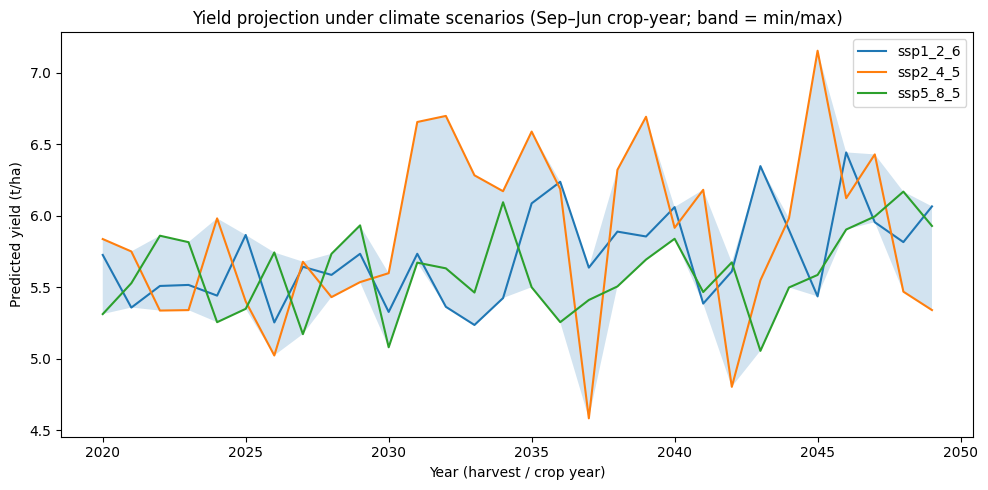

In [123]:
df_future["yield_pred"] = best_pipe.predict(df_future[feature_cols])

# --- Plot average across departments (like before)
pred_year_scen = (
    df_future.groupby(["year", "scenario"], as_index=False)["yield_pred"]
    .mean()
)

wide = pred_year_scen.pivot(index="year", columns="scenario", values="yield_pred").sort_index()
ymin, ymax = wide.min(axis=1), wide.max(axis=1)

plt.figure(figsize=(10,5))
for scen in scenarios:
    if scen in wide.columns:
        plt.plot(wide.index, wide[scen], label=scen)

plt.fill_between(wide.index, ymin, ymax, alpha=0.2)
plt.title("Yield projection under climate scenarios (Sep–Jun crop-year; band = min/max)")
plt.xlabel("Year (harvest / crop year)")
plt.ylabel("Predicted yield (t/ha)")
plt.legend()
plt.tight_layout()
plt.show()

Rows selected: 90


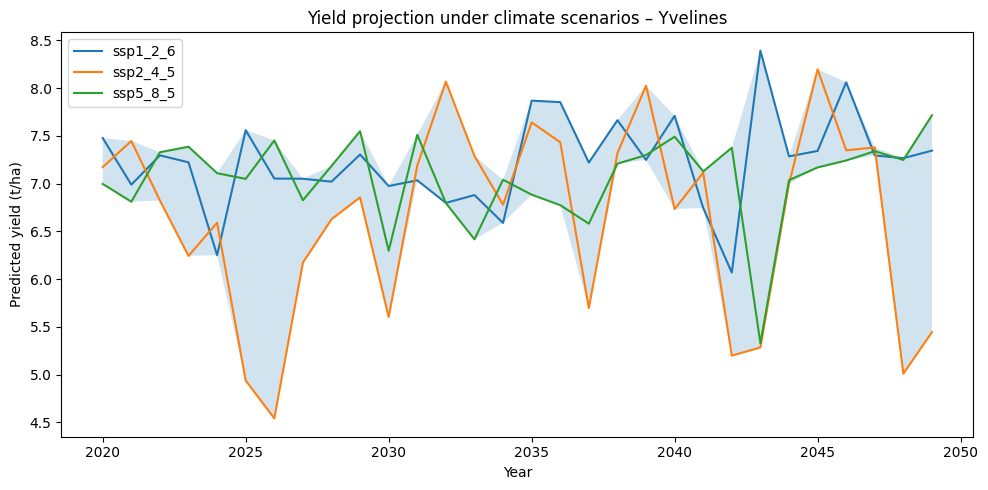

In [124]:
import matplotlib.pyplot as plt

# ==============================
# 1️⃣  Choose department
# ==============================
dep_name = "Yvelines"   # <-- change this

future_years = list(range(2020, 2050))
scenarios = ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]

# ==============================
# 2️⃣  Filter future data
# ==============================
df_dep = cl_season_wide[
    (cl_season_wide["department"] == dep_name) &
    (cl_season_wide["year"].isin(future_years)) &
    (cl_season_wide["scenario"].isin(scenarios))
].copy()

print("Rows selected:", df_dep.shape[0])

if df_dep.empty:
    raise ValueError("No data found for this department. Check spelling.")

# ==============================
# 3️⃣  Predict yield
# ==============================
df_dep["yield_pred"] = best_pipe.predict(df_dep[feature_cols])

# ==============================
# 4️⃣  Pivot for plotting
# ==============================
wide = (
    df_dep.groupby(["year","scenario"])["yield_pred"]
    .mean()
    .unstack("scenario")
    .sort_index()
)

ymin = wide.min(axis=1)
ymax = wide.max(axis=1)

# ==============================
# 5️⃣  Plot
# ==============================
plt.figure(figsize=(10,5))

for scen in scenarios:
    if scen in wide.columns:
        plt.plot(wide.index, wide[scen], label=scen)

plt.fill_between(wide.index, ymin, ymax, alpha=0.2)

plt.title(f"Yield projection under climate scenarios – {dep_name}")
plt.xlabel("Year")
plt.ylabel("Predicted yield (t/ha)")
plt.legend()
plt.tight_layout()
plt.show()

## KPIs

In [209]:
window_mask = (df_future["year"] >= 2019) & (df_future["year"] <= 2030)
scen = "ssp2_4_5"  # choose scenario for risk ranking

df_win = df_future[
    window_mask & (df_future["scenario"] == scen)
].copy()

In [210]:
risk_table = (
    df_win
    .groupby("department")["yield_pred"]
    .agg(
        future_mean="mean",
        future_std="std",
        p10=lambda x: np.percentile(x, 10),
        worst="min"
    )
    .reset_index()
)

In [211]:
hist_mask = (df_merged["year"] >= 2000) & (df_merged["year"] <= 2018)

hist_mean = (
    df_merged[hist_mask]
    .groupby("department")["yield"]
    .mean()
    .reset_index()
    .rename(columns={"yield": "historical_mean"})
)

risk_table = risk_table.merge(hist_mean, on="department", how="left")

In [212]:
deps_gdf = gpd.read_file("https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson")
deps_gdf.columns

Index(['code', 'nom', 'geometry'], dtype='str')

In [213]:
risk_table["downside_gap"] = (
    risk_table["historical_mean"] - risk_table["p10"]
)

In [214]:
# average cultivated area
area_df = (
    barley_clean.groupby("department")["area"]
    .mean()
    .reset_index()
)

risk_table = risk_table.merge(area_df, on="department", how="left")

risk_table["loss_tonnes"] = risk_table["downside_gap"] * risk_table["area"]

price = 0.22  # €/tonne (adjust if needed)

risk_table["loss_eur"] = risk_table["loss_tonnes"] * price

In [215]:
risk_table["cv"] = risk_table["future_std"] / risk_table["future_mean"]

In [216]:
# Normalize components
risk_table["p10_norm"] = (
    (risk_table["p10"] - risk_table["p10"].min()) /
    (risk_table["p10"].max() - risk_table["p10"].min())
)

risk_table["vol_norm"] = (
    (risk_table["future_std"] - risk_table["future_std"].min()) /
    (risk_table["future_std"].max() - risk_table["future_std"].min())
)

# Higher score = worse risk
risk_table["risk_score"] = (
    (1 - risk_table["p10_norm"]) * 0.7 +
    risk_table["vol_norm"] * 0.3
)

In [217]:
risk_table = risk_table.sort_values("loss_tonnes", ascending=False)

risk_table.head(10)

,department,future_mean,future_std,p10,worst,historical_mean,downside_gap,area,loss_tonnes,loss_eur,cv,p10_norm,vol_norm,risk_score
58,Marne,6.1771,1.3917,5.5355,2.8769,7.1058,1.5703,"88,410.9730","138,832.3793","30,543.1234",0.2253,0.6607,0.9794,0.5313
19,Cote_d_Or,4.8012,0.8192,4.1742,3.0039,5.8496,1.6754,"75,453.7838","126,416.9663","27,811.7326",0.1706,0.3445,0.4832,0.6038
8,Aube,6.4589,0.9948,5.4305,4.3418,6.8868,1.4563,"73,547.3784","107,108.3010","23,563.8262",0.1540,0.6363,0.6354,0.4452
28,Eure_et_Loir,6.3369,1.0368,5.3969,4.1880,7.4337,2.0368,"52,122.7297","106,161.4191","23,355.5122",0.1636,0.6285,0.6717,0.4615
68,Pas_de_Calais,7.0858,1.0368,6.2346,4.6007,7.8360,1.6014,"58,919.5135","94,354.5725","20,758.0059",0.1463,0.8231,0.6718,0.3254
61,Meuse,5.8020,0.9261,4.6125,4.0504,6.0384,1.4259,"58,085.7297","82,824.9702","18,221.4935",0.1596,0.4463,0.5759,0.5603
1,Aisne,6.5112,0.9874,5.3266,4.2781,7.1360,1.8094,"42,883.8378","77,593.1050","17,070.4831",0.1517,0.6122,0.6290,0.4602
52,Loiret,5.6017,1.0280,5.0039,3.3507,6.4605,1.4566,"51,764.7568","75,401.9577","16,588.4307",0.1835,0.5372,0.6641,0.5232
87,Yonne,5.7822,0.8220,4.9054,4.0779,6.0231,1.1177,"67,240.8919","75,155.2704","16,534.1595",0.1422,0.5144,0.4856,0.4856
78,Somme,7.2053,0.5416,6.2860,6.1169,7.7435,1.4575,"51,025.4054","74,369.4940","16,361.2887",0.0752,0.8350,0.2427,0.1883


In [218]:
risk_table[risk_table["loss_tonnes"] > 0]['loss_tonnes'].sum()

np.float64(2144713.631045261)

## MAPS

In [219]:
def norm_name(s):
    if pd.isna(s):
        return s
    
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = s.replace(" ", "_").replace("-", "_").replace("'", "_")
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

# 1) Create merge key in geo file
deps_gdf["dep_key"] = deps_gdf["nom"].map(norm_name)   # <-- change 'nom' if needed

# 2) Create merge key in your risk table
risk_map = risk_table.copy()
risk_map["dep_key"] = risk_map["department"].map(norm_name)

# Optional: manual fixes for a few tricky names (add if needed)
fixes = {
    # "cote_d_or": "cote_d_or",
    # "pyrenees_Atlantiques": "pyrenees_atlantiques",
    # "seine_seineoisee": ??? (this one likely won't exist)
}
risk_map["dep_key"] = risk_map["dep_key"].replace(fixes)

# Merge
plot_gdf = deps_gdf.merge(
    risk_map[["dep_key", "risk_score", "p10", "loss_eur"]],
    on="dep_key",
    how="left"
)

print("Matched rows:", plot_gdf["risk_score"].notna().sum(), "/", len(plot_gdf))

Matched rows: 89 / 96


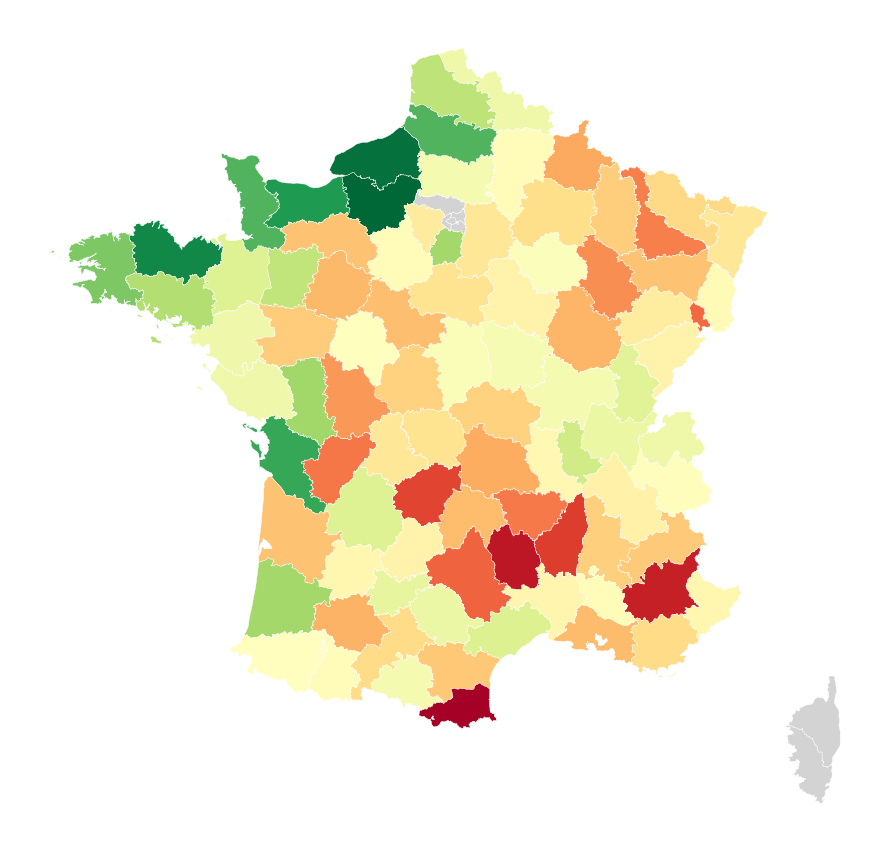

In [220]:
# Choose what you want to color by:
metric = "risk_score"      # or "p10" (lower worse), or "loss_eur" (higher worse)

# If using p10, invert so "higher = worse" for coloring
if metric == "p10":
    plot_gdf["metric_to_plot"] = -plot_gdf["p10"]
else:
    plot_gdf["metric_to_plot"] = plot_gdf[metric]

fig, ax = plt.subplots(1, 1, figsize=(9, 10))

plot_gdf.plot(
    column="risk_score",        # or "loss_eur", or inverted p10
    cmap="RdYlGn_r",            # _r reverses it
    legend=False,
    linewidth=0.3,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

ax.axis("off")
plt.tight_layout()
plt.show()

In [221]:
risk_table.to_excel(
    "risk_table_2019_2050.xlsx",
    index=False
)